In [1]:
# Load Iris from scikit-learn and (optionally) save it locally as .npz using NumPy
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data          # shape (150, 4)
y = iris.target        # shape (150,)
feature_names = np.array(iris.feature_names)
target_names = np.array(iris.target_names)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("feature_names:", feature_names)
print("target_names:", target_names)


print("Saved: iris_sklearn.npz")

X shape: (150, 4)
y shape: (150,)
feature_names: ['sepal length (cm)' 'sepal width (cm)' 'petal length (cm)'
 'petal width (cm)']
target_names: ['setosa' 'versicolor' 'virginica']
Saved: iris_sklearn.npz


BOXPLOTS PR FATURE

C:\Users\39346\AppData\Local\Temp\ipykernel_17784\332183849.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X, labels=feature_names, showmeans=True)


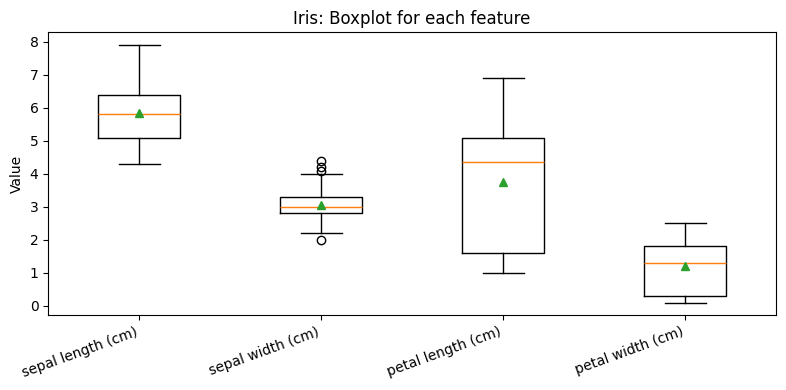

In [10]:
import matplotlib.pyplot as plt
# Boxplot for each feature (4 boxplots in one figure)
plt.figure(figsize=(8, 4))
plt.boxplot(X, labels=feature_names, showmeans=True)
plt.xticks(rotation=20, ha="right")
plt.ylabel("Value")
plt.title("Iris: Boxplot for each feature")
plt.tight_layout()
plt.show()

C:\Users\39346\AppData\Local\Temp\ipykernel_17784\3024392425.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=target_names, showmeans=True)
C:\Users\39346\AppData\Local\Temp\ipykernel_17784\3024392425.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=target_names, showmeans=True)
C:\Users\39346\AppData\Local\Temp\ipykernel_17784\3024392425.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=target_names, showmeans=True)
C:\Users\39346\AppData\Local\Temp\ipykernel_17784\3024392425.py:8: MatplotlibDeprecationWarning: 

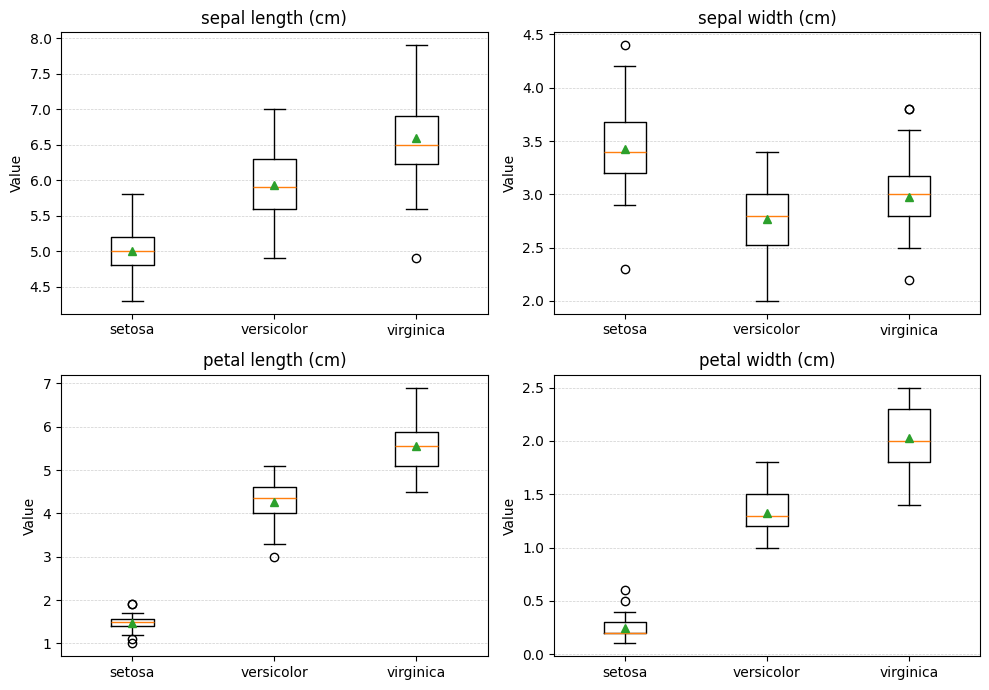

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

for j, ax in enumerate(axes):
    # Collect data for feature j, split by class
    data_by_class = [X[y == c, j] for c in range(len(target_names))]

    ax.boxplot(data_by_class, labels=target_names, showmeans=True)
    ax.set_title(feature_names[j])
    ax.set_ylabel("Value")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

If the split reduces entropy → we gain information

In [14]:
print(X[:,0])

[5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9 5.4 4.8 4.8 4.3 5.8 5.7 5.4 5.1
 5.7 5.1 5.4 5.1 4.6 5.1 4.8 5.  5.  5.2 5.2 4.7 4.8 5.4 5.2 5.5 4.9 5.
 5.5 4.9 4.4 5.1 5.  4.5 4.4 5.  5.1 4.8 5.1 4.6 5.3 5.  7.  6.4 6.9 5.5
 6.5 5.7 6.3 4.9 6.6 5.2 5.  5.9 6.  6.1 5.6 6.7 5.6 5.8 6.2 5.6 5.9 6.1
 6.3 6.1 6.4 6.6 6.8 6.7 6.  5.7 5.5 5.5 5.8 6.  5.4 6.  6.7 6.3 5.6 5.5
 5.5 6.1 5.8 5.  5.6 5.7 5.7 6.2 5.1 5.7 6.3 5.8 7.1 6.3 6.5 7.6 4.9 7.3
 6.7 7.2 6.5 6.4 6.8 5.7 5.8 6.4 6.5 7.7 7.7 6.  6.9 5.6 7.7 6.3 6.7 7.2
 6.2 6.1 6.4 7.2 7.4 7.9 6.4 6.3 6.1 7.7 6.3 6.4 6.  6.9 6.7 6.9 5.8 6.8
 6.7 6.7 6.3 6.5 6.2 5.9]


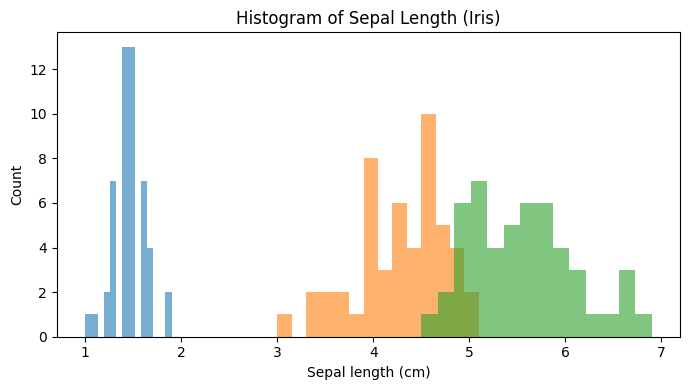

In [16]:
sepal_length = X[:, 0]  # sepal length (cm)

plt.figure(figsize=(7, 4))
for c, name in enumerate(target_names):
    plt.hist(X[y == c, 2], bins=14, alpha=0.6, label=name)
plt.title("Histogram of Sepal Length (Iris)")
plt.xlabel("Sepal length (cm)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [20]:
print(X[:,0].size)

150


Compute entropy

In [21]:
import math
counts = [X[:,0].size,X[:,1].size,X[:,2].size]
total = sum(counts)
H = 0.0

for count in counts:
    if count == 0:
        continue  # skip zero counts (since 0*log(0) = 0)
    p = count / total
    H -= p * math.log2(p)
    
print(H)

1.584962500721156


In [18]:
import numpy as np
import math
from collections import Counter

def entropy(labels):
    total = len(labels)
    counter = Counter(labels)
    H = 0.0
    for count in counter.values():
        p = count / total
        H -= p * math.log2(p)
    return H

def best_split(feature_vals, labels):
    # Sort by feature_vals
    sorted_idx = np.argsort(feature_vals)
    feature_vals = feature_vals[sorted_idx]
    # print(feature_vals)
    labels = labels[sorted_idx]
    
    parent_entropy = entropy(labels)
    best_ig = 0
    best_threshold = None
    
    # Candidate thresholds
    for i in range(1, len(feature_vals)):
        if feature_vals[i] == feature_vals[i-1]:
            continue
        
        t = (feature_vals[i] + feature_vals[i-1]) / 2
        
        left_labels = labels[:i]
        right_labels = labels[i:]
        
        H_left = entropy(left_labels)
        H_right = entropy(right_labels)
        
        N = len(labels)
        H_after = (len(left_labels)/N)*H_left + \
                  (len(right_labels)/N)*H_right
        
        ig = parent_entropy - H_after
        
        if ig > best_ig:
            best_ig = ig
            best_threshold = t
    
    return best_threshold, best_ig

feature_index = 3  # sepal length
threshold, ig = best_split(X[:, feature_index], y)
print(f"Best threshold for feature {feature_index}: {threshold:.3f}, Information Gain: {ig:.4f}")

Best threshold for feature 3: 0.800, Information Gain: 0.9183


In [ ]:
current_best_threshold, current_best_ig, f_split = 0, 0, 0
splits = {}
X_dx, X_sx = X 

for i in range(3):
    for f  in range(feature_names.size):
        threshold,ig = best_split(X[:,f],y)
        if(ig > current_best_ig):
            current_best_ig = ig
            current_best_threshold = threshold
            f_split = f
        curr_split = {}
        curr_split["feature"] = feature_names[f]
        curr_split["bst_threshold"] = current_best_threshold
        splits[f] = curr_split

X_dx  = X[X[:, f] <= current_best_threshold]
X_sx = X[X[:, f] > current_best_threshold]
    
print(splits)
# print(X_dx[X_dx[:,f_split]> current_best_threshold]  )
# X[X[:, ] > threshold]

print(f"Best threshold across all features: {current_best_threshold:.3f}, Information Gain: {current_best_ig:.4f}, on feature: {f}")
    

{0: {'feature': 'sepal length (cm)', 'bst_threshold': 5.55}, 1: {'feature': 'sepal width (cm)', 'bst_threshold': 5.55}, 2: {'feature': 'petal length (cm)', 'bst_threshold': 2.45}, 3: {'feature': 'petal width (cm)', 'bst_threshold': 2.45}}
Best threshold across all features: 2.450, Information Gain: 0.9183, on feature: 3
